**Predicting Loan Approval Decisions Using Machine Learning Classification Models**

- Overview

This project focuses on predicting loan approval status using machine learning techniques. The dataset contains applicant demographic, financial, employment, and credit-related information that can help determine whether a loan application is likely to be approved.

The objective is to build an intelligent classification model capable of assisting financial institutions in making faster, more consistent, and data-driven lending decisions.

In [161]:
# %pip install -q kagglehub

In [162]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


#### **Requirement Gathering, Data Source**

In [194]:
import os
import kagglehub
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

%matplotlib inline

def show_layout():
    plt.figure(figsize=(9, 4))
    plt.tight_layout()
    plt.show()

In [195]:
# Download latest version
path = kagglehub.dataset_download("muhammadmusharraf444/loan-approval-dataset")
source_path = path
destination_path = os.getcwd()

# Copy dataset from source directory to destination directory
source_path = path
destination_path = os.getcwd()

shutil.copytree(source_path, destination_path, dirs_exist_ok = True)

Using Colab cache for faster access to the 'loan-approval-dataset' dataset.


'/content'

In [196]:
source_path

'/kaggle/input/loan-approval-dataset'

In [197]:
loan_df = pd.read_csv("./loan_data_new.csv")
loan_df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


#### **Dataset Overview**

In [198]:
print(f"Rows: {loan_df.shape[0]}, Columns: {loan_df.shape[1]}")
print(loan_df.columns.to_list())
print(loan_df.isna().sum())
print(loan_df.info())

Rows: 45000, Columns: 14
['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience', 'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan', 'Loan Status']
Age                    0
Gender                 0
Education              0
Person Income          0
Employee Experience    0
Home Onwership         0
Loan Amount            0
Loan Intent            0
Loan interest Rate     0
Loan percentage        0
Credit History         0
Credit Score           0
Previous Loan          0
Loan Status            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        4

In [199]:
print(f"{loan_df.duplicated().sum()} duplicate/s was found in this dataset")

0 duplicate/s was found in this dataset


#### **Cleaning and Standardization**

In [200]:
loan_df.columns = (loan_df.columns.str.strip().str.replace(" ", "_").str.lower())
loan_df = loan_df.rename(columns={"home_onwership": "home_ownership"})

# Identify columns with 'object' dtype (typically strings)
textual_cols = loan_df.select_dtypes(include='object').columns

for col in textual_cols:
    loan_df[col] = loan_df[col].str.lower()

In [201]:
# loan_df['loan_status'] = loan_df['loan_status'].map({"Yes": 1, "No": 0})

numerical_cols = loan_df.select_dtypes([np.number]).columns.to_list()
categorical_cols = [col for col in loan_df.columns if col not in numerical_cols]

print(numerical_cols)
print(categorical_cols)

['age', 'person_income', 'employee_experience', 'loan_amount', 'loan_interest_rate', 'loan_percentage', 'credit_history', 'credit_score', 'loan_status']
['gender', 'education', 'home_ownership', 'loan_intent', 'previous_loan']


### **Univariate Analysis**

In [171]:
print("Summary statistics for numerical columns:")
print(loan_df[numerical_cols].describe().head())
print(loan_df[numerical_cols].isna().sum())

Summary statistics for numerical columns:
                age  person_income  employee_experience   loan_amount  \
count  45000.000000   45000.000000         45000.000000  45000.000000   
mean      27.764178   80319.053222             5.410333   9583.157556   
std        6.045108   80422.498632             6.063532   6314.886691   
min       20.000000    8000.000000             0.000000    500.000000   
25%       24.000000   47204.000000             1.000000   5000.000000   

       loan_interest_rate  loan_percentage  credit_history  credit_score  \
count        45000.000000     45000.000000    45000.000000  45000.000000   
mean            11.006606         0.139725        5.867489    632.608756   
std              2.978808         0.087212        3.879702     50.435865   
min              5.420000         0.000000        2.000000    390.000000   
25%              8.590000         0.070000        3.000000    601.000000   

        loan_status  
count  45000.000000  
mean       0.22222

In [202]:
numerical_summary = loan_df[numerical_cols].agg(["mean", "var", "std"])
numerical_summary

,age,person_income,employee_experience,loan_amount,loan_interest_rate,loan_percentage,credit_history,credit_score,loan_status
mean,27.764178,8.031905e+04,5.410333,9.583158e+03,11.006606,0.139725,5.867489,632.608756,0.222222
var,36.543333,6.467778e+09,36.766421,3.987779e+07,8.873299,0.007606,15.052086,2543.776478,0.172843
std,6.045108,8.042250e+04,6.063532,6.314887e+03,2.978808,0.087212,3.879702,50.435865,0.415744


In [207]:
print(loan_df[numerical_cols].skew()) # type: ignoreow
print(loan_df[numerical_cols].kurtosis()) # type: ignore

age                     2.548154
person_income          34.137583
employee_experience     2.594917
loan_amount             1.179731
loan_interest_rate      0.213784
loan_percentage         1.034512
credit_history          1.631720
credit_score           -0.610261
loan_status             1.336351
dtype: float64
age                      18.649449
person_income          2398.684769
employee_experience      19.168324
loan_amount               1.351215
loan_interest_rate       -0.420335
loan_percentage           1.082416
credit_history            3.725945
credit_score              0.203022
loan_status              -0.214176
dtype: float64


In [204]:
age_counts = loan_df["age"].value_counts().sort_index()
print(age_counts.head())

age
20      17
21    1289
22    4236
23    5254
24    5138
Name: count, dtype: int64


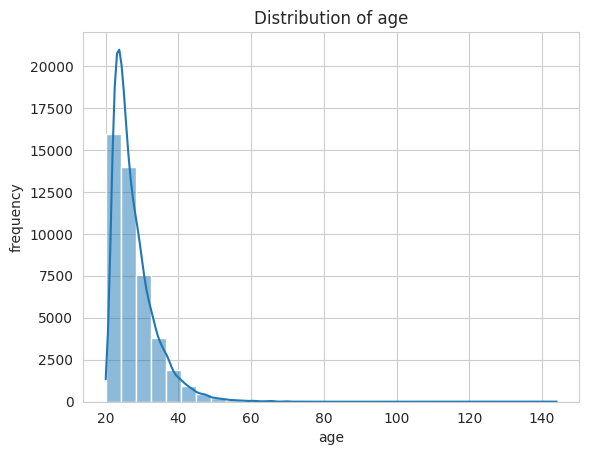

<Figure size 900x400 with 0 Axes>

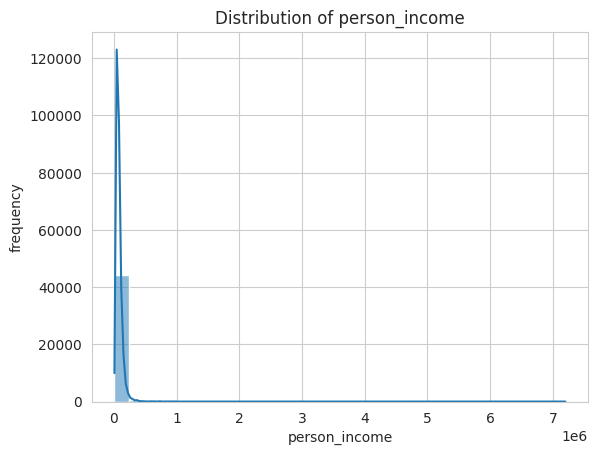

<Figure size 900x400 with 0 Axes>

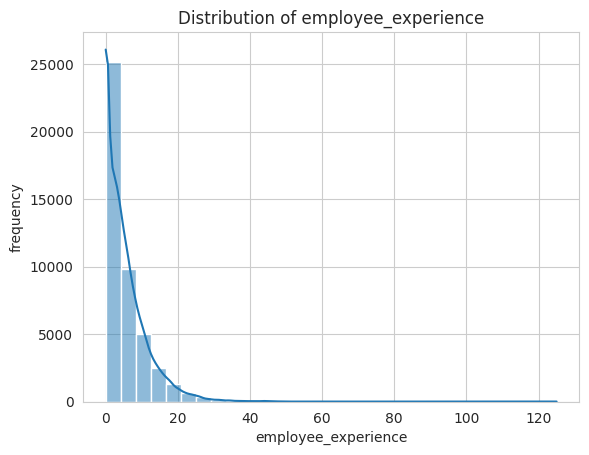

<Figure size 900x400 with 0 Axes>

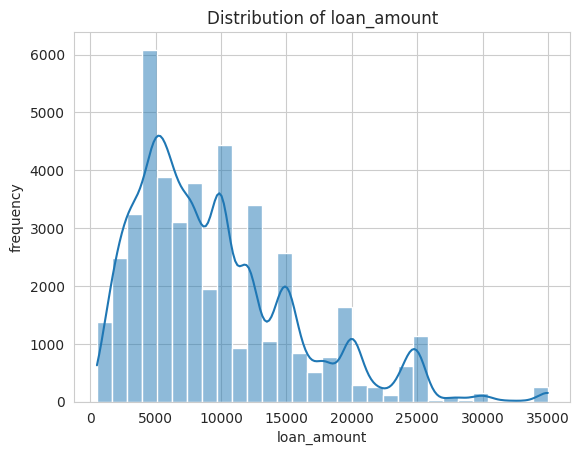

<Figure size 900x400 with 0 Axes>

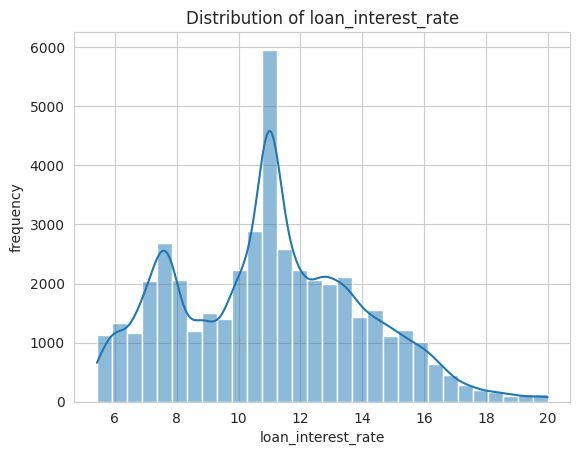

<Figure size 900x400 with 0 Axes>

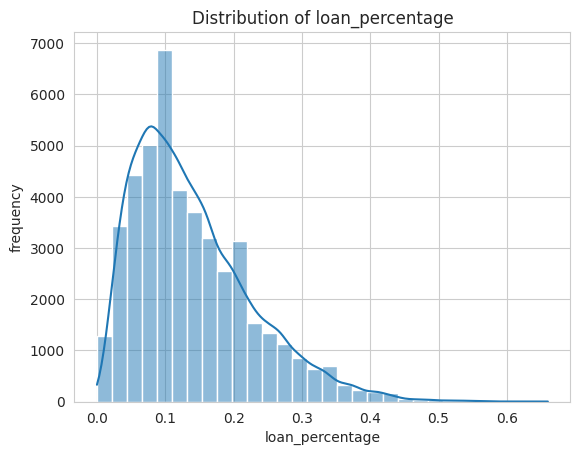

<Figure size 900x400 with 0 Axes>

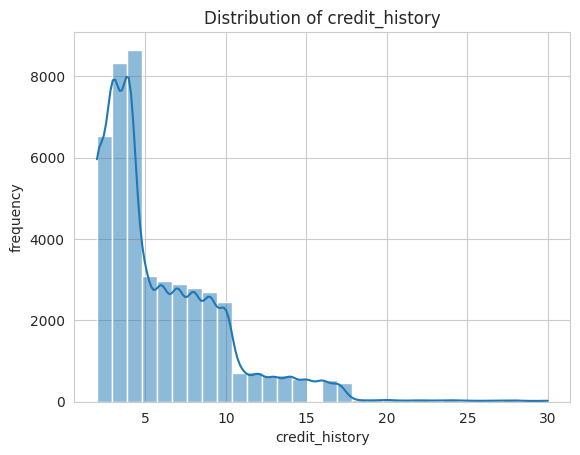

<Figure size 900x400 with 0 Axes>

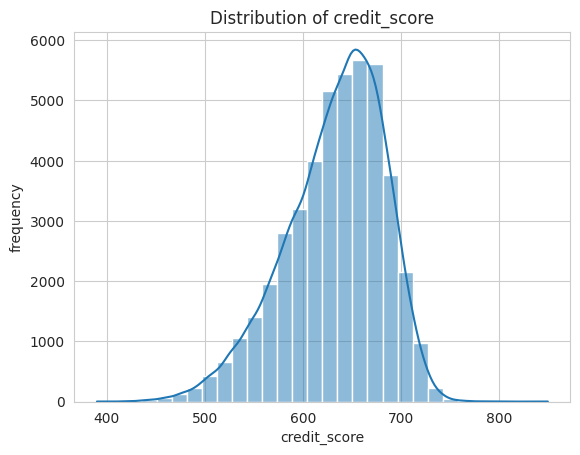

<Figure size 900x400 with 0 Axes>

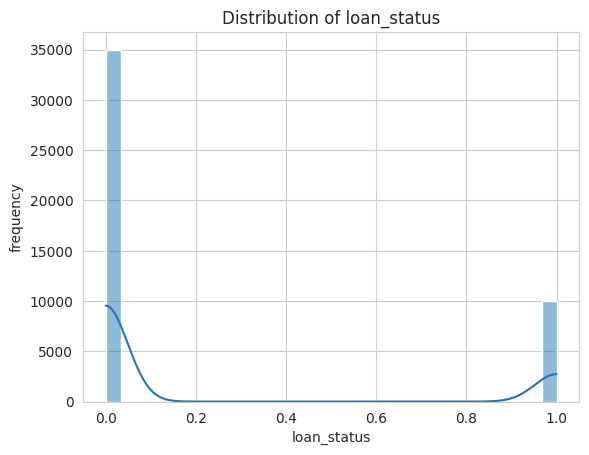

<Figure size 900x400 with 0 Axes>

In [241]:
for cols in numerical_cols:
    sns.histplot(x = loan_df[cols], kde = True, bins = 30)
    plt.title(f"Distribution of {cols}")
    plt.xlabel(cols)
    plt.ylabel("frequency")
    show_layout()

#### **Exploratory Data Analysis**

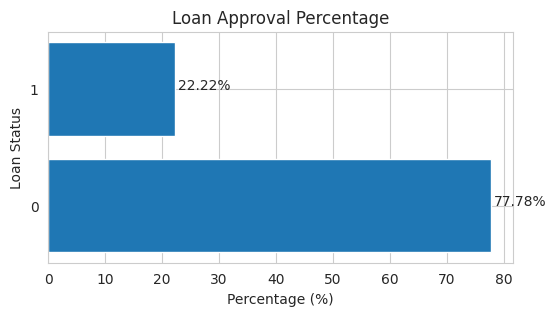

In [223]:
loan_approved_percentage = (
    loan_df['loan_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(6,3))
plt.barh(loan_approved_percentage.index.astype(str),
         loan_approved_percentage.values)

plt.xlabel('Percentage (%)')
plt.ylabel('Loan Status')
plt.title('Loan Approval Percentage')

for i, v in enumerate(loan_approved_percentage.values):
    plt.text(v + 0.5, i, f'{v:.2f}%')

plt.show()

# Highly imbalanced dataset, 78% of loan request were rejected whilst only 22% were accepted, since the model is right 78% of the time, it'll treat others as same (reject)

In [224]:
# loan_approved_percentage = (
#     loan_df['loan_status']
#     .replace({0: 'Rejected', 1: 'Approved'})
#     .value_counts(normalize=True)
#     .mul(100)
#     .round(2)
# )

# plt.barh(loan_approved_percentage.index, loan_approved_percentage.values)
# plt.xlabel('Percentage (%)')
# plt.title('Loan Approval Percentage')
# plt.show()

In [225]:
salary_threshold = loan_df["person_income"].mean()
print(f"Salary threshold: {round((salary_threshold),2)}")

Salary threshold: 80319.05


In [231]:
# 1. Do applicants with higher incomes get approved more often?
higher_income_group = loan_df[loan_df.loc[:, "person_income"] >= salary_threshold]
lower_income_group = loan_df[loan_df.loc[:, "person_income"] < salary_threshold]

# 2. Extract the exact approval rates
high_income_approval = (higher_income_group["loan_status"] == 1).mean() * 100
low_income_approval = (lower_income_group["loan_status"] == 1).mean() * 100

# 3. Loan approval differences
print(f"High income loan approval rate: {high_income_approval:.2f}%")
print(f"Low income loan approval rate: {low_income_approval:.2f}%")
print(f"Difference in approval rates: {high_income_approval - low_income_approval:.2f}%")

High income loan approval rate: 13.23%
Low income loan approval rate: 31.21%
Difference in approval rates: -17.98%


In [232]:
# Does education level affect approval rates?
education_approval_rate = (
    loan_df.groupby("education")["loan_status"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(education_approval_rate)

education
doctorate      22.87
bachelor       22.52
high school    22.31
associate      22.03
master         21.76
Name: loan_status, dtype: float64


In [179]:
target_column = "loan_status"

In [236]:
print(f"Rows before dropping missing target values: {loan_df.shape[0]}")

missing_target_count = loan_df[target_column].isna().sum()
print(f"Missing values in '{target_column}': {missing_target_count}")

# Drop rows with missing target values
loan_df.dropna(subset=[target_column], inplace=True)

print(f"Rows after dropping missing target values: {loan_df.shape[0]}")
print(f"Rows removed: {missing_target_count}")

Rows before dropping missing target values: 45000
Missing values in 'loan_status': 0
Rows after dropping missing target values: 45000
Rows removed: 0


### **Feature & Target Separation**

In [237]:
X = loan_df.drop(columns=[target_column], axis=1)
y = loan_df[target_column]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (45000, 13)
Target Shape: (45000,)


In [238]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.2,
    random_state=42,
    stratify= y
)

In [240]:
print("Target Distribution Full dataset")
print(y.value_counts(normalize=True).round(3))

print("-"*20)
print("Target Distribution Train set")
print(y_train.value_counts(normalize=True).round(3))

print("-"*20)
print("Target Distribution Test set")
print(y_test.value_counts(normalize=True).round(3))

Target Distribution Full dataset
loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64
--------------------
Target Distribution Train set
loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64
--------------------
Target Distribution Test set
loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64


In [239]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(36000, 13)
(36000,)
(9000, 13)
(9000,)


In [185]:
# Preservability
Loan_Train_df = X_train.copy()
Loan_Train_df[target_column] = y_train.values

Loan_Test_df = X_test.copy()
Loan_Test_df[target_column] = y_test.values

In [186]:
Loan_train_encoder = Loan_Train_df.copy()
Loan_test_encoder = Loan_Test_df.copy()

In [242]:
def multi_line_space():
    print()

print("X_Train Columns:", Loan_train_encoder.columns)
multi_line_space()
print("X_Test Columns:", Loan_test_encoder.columns)

X_train Columns:
Index(['age', 'gender', 'education', 'person_income', 'employee_experience',
       'home_ownership', 'loan_amount', 'loan_intent', 'loan_interest_rate',
       'loan_percentage', 'credit_history', 'credit_score', 'previous_loan',
       'loan_status'],
      dtype='object')

X_test Columns:
Index(['age', 'gender', 'education', 'person_income', 'employee_experience',
       'home_ownership', 'loan_amount', 'loan_intent', 'loan_interest_rate',
       'loan_percentage', 'credit_history', 'credit_score', 'previous_loan',
       'loan_status'],
      dtype='object')


### **Feature Encoding**

In [243]:
target_column = "loan_status"

log_numeric_cols = ["person_income", "loan_amount"]
plain_numeric_cols = ["age", "employee_experience", "loan_interest_rate",
                      "loan_percentage", "credit_history", "credit_score"]

ordinal_cols = ["education"]
education_order = ["high school", "associate", "bachelor", "master", "doctorate"]

binary_cols = ["gender", "previous_loan"]
nominal_cols = ["loan_intent", "home_ownership"]

In [244]:
all_cols = (log_numeric_cols + plain_numeric_cols + ordinal_cols
            + binary_cols + nominal_cols + [target_column])

print(sorted(all_cols) == sorted(loan_df.columns.tolist()))
print(set(loan_df.columns) - set(all_cols))   # should print an empty set

True
set()


In [245]:
from sklearn.preprocessing import OrdinalEncoder

education_encoder = OrdinalEncoder(
    categories=[education_order],          # the order list from Step 1
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

education_encoder.fit(X_train[["education"]])

X_train["education"] = education_encoder.transform(X_train[["education"]])
X_test["education"] = education_encoder.transform(X_test[["education"]])

In [246]:
print(X_train["education"].unique())
print(X_test["education"].unique())

[3. 0. 2. 1. 4.]
[2. 1. 0. 3. 4.]


In [247]:
print(X_train["gender"].unique())
print(X_train["previous_loan"].unique())

['male' 'female']
['yes' 'no']


In [251]:
from sklearn.preprocessing import OrdinalEncoder

binary_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Fitting the columns
binary_encoder.fit(X_train[binary_cols])

# Train & Test
X_train[binary_cols] = binary_encoder.transform(X_train[binary_cols])
X_test[binary_cols] = binary_encoder.transform(X_test[binary_cols])

In [256]:
from sklearn.preprocessing import OneHotEncoder

nominal_encoder = OneHotEncoder(
    drop = "first",
    sparse_output = False,
    handle_unknown = "ignore"
    )

nominal_encoder.fit(X_train[nominal_cols])

X_train_nominal = nominal_encoder.transform(X_train[nominal_cols])
X_test_nominal = nominal_encoder.transform(X_test[nominal_cols])

In [257]:
print(X_train_nominal.shape)
print(X_test_nominal.shape)
print(nominal_encoder.get_feature_names_out(nominal_cols))

(36000, 8)
(9000, 8)
['loan_intent_education' 'loan_intent_homeimprovement'
 'loan_intent_medical' 'loan_intent_personal' 'loan_intent_venture'
 'home_ownership_other' 'home_ownership_own' 'home_ownership_rent']


### **Feature Scaling**

In [258]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# --- 5a. Log-transform the skewed columns first ---
X_train[log_numeric_cols] = np.log1p(X_train[log_numeric_cols])
X_test[log_numeric_cols] = np.log1p(X_test[log_numeric_cols])

# --- 5b. Scale ALL numeric columns (log-transformed + plain) ---
all_numeric_cols = log_numeric_cols + plain_numeric_cols

numeric_scaler = StandardScaler()

# Fit ONLY on train
numeric_scaler.fit(X_train[all_numeric_cols])

# Transform both
X_train[all_numeric_cols] = numeric_scaler.transform(X_train[all_numeric_cols])
X_test[all_numeric_cols] = numeric_scaler.transform(X_test[all_numeric_cols])

In [260]:
X_train[all_numeric_cols].describe().loc[["mean", "std"]]

,person_income,loan_amount,age,employee_experience,loan_interest_rate,loan_percentage,credit_history,credit_score
mean,1.903860e-15,-2.122944e-15,2.644798e-17,3.397282e-17,6.240934e-16,-4.894850e-17,8.131767e-17,-1.225193e-16
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00


In [261]:
# 6a. Turn the one-hot arrays into proper DataFrames with real column names
nominal_feature_names = nominal_encoder.get_feature_names_out(nominal_cols)

X_train_nominal_df = pd.DataFrame(
    X_train_nominal,
    columns=nominal_feature_names,
    index=X_train.index      # critical — see explanation below
)

X_test_nominal_df = pd.DataFrame(
    X_test_nominal,
    columns=nominal_feature_names,
    index=X_test.index
)

# 6b. Drop the original text columns from X_train / X_test
X_train_final = X_train.drop(columns=nominal_cols)
X_test_final = X_test.drop(columns=nominal_cols)

# 6c. Attach the one-hot columns
X_train_final = pd.concat([X_train_final, X_train_nominal_df], axis=1)
X_test_final = pd.concat([X_test_final, X_test_nominal_df], axis=1)

In [262]:
print(X_train_final.shape)
print(X_test_final.shape)
print(X_train_final.columns.tolist())
print(X_train_final.isna().sum().sum())   # should be 0

(36000, 19)
(9000, 19)
['age', 'gender', 'education', 'person_income', 'employee_experience', 'loan_amount', 'loan_interest_rate', 'loan_percentage', 'credit_history', 'credit_score', 'previous_loan', 'loan_intent_education', 'loan_intent_homeimprovement', 'loan_intent_medical', 'loan_intent_personal', 'loan_intent_venture', 'home_ownership_other', 'home_ownership_own', 'home_ownership_rent']
0


In [263]:
# 1. Confirm every column is now numeric — no leftover text/object columns
print(X_train_final.dtypes.value_counts())

# 2. Confirm train and test have identical columns, same order
print(list(X_train_final.columns) == list(X_test_final.columns))

# 3. Final shapes
print("Train:", X_train_final.shape)
print("Test:", X_test_final.shape)

# 4. Quick peek at the actual values
X_train_final.head()

float64    19
Name: count, dtype: int64
True
Train: (36000, 19)
Test: (9000, 19)


,age,gender,education,person_income,employee_experience,loan_amount,loan_interest_rate,loan_percentage,credit_history,credit_score,previous_loan,loan_intent_education,loan_intent_homeimprovement,loan_intent_medical,loan_intent_personal,loan_intent_venture,home_ownership_other,home_ownership_own,home_ownership_rent
6048,-0.622502,1.0,3.0,-0.249235,-0.561597,-0.779194,-1.687749,-0.800883,-0.480436,0.464300,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3346,-0.787921,0.0,0.0,-0.696279,-0.561597,0.512067,-0.001061,1.154322,-0.996078,0.026852,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
17998,0.204591,0.0,3.0,2.267396,0.262920,0.377746,0.563408,-1.145920,0.808671,0.106388,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
24988,0.370009,0.0,2.0,0.629047,0.757630,-0.342136,0.832203,-0.915896,0.550850,0.981285,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
23231,0.204591,1.0,2.0,0.134614,0.262920,0.063275,-0.169058,-0.340835,0.550850,0.225692,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### **Baseline Model, Logistic Regression**

In [267]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train_final, y_train)

y_pred = log_reg.predict(X_test_final)

In [268]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[5928 1072]
 [ 145 1855]]
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7000
           1       0.63      0.93      0.75      2000

    accuracy                           0.86      9000
   macro avg       0.80      0.89      0.83      9000
weighted avg       0.90      0.86      0.87      9000



### **Random Forest Modeling**

In [269]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train)

y_pred_rf = rf_model.predict(X_test_final)

In [270]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[6256  744]
 [ 192 1808]]
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      7000
           1       0.71      0.90      0.79      2000

    accuracy                           0.90      9000
   macro avg       0.84      0.90      0.86      9000
weighted avg       0.91      0.90      0.90      9000



### **Feature Importance**

In [271]:
import pandas as pd

feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train_final.columns
).sort_values(ascending=False)

print(feature_importances)

previous_loan                  0.469045
loan_interest_rate             0.145382
loan_percentage                0.143718
person_income                  0.094887
home_ownership_rent            0.053114
loan_amount                    0.027088
credit_score                   0.013531
home_ownership_own             0.012298
loan_intent_venture            0.010009
age                            0.005390
loan_intent_homeimprovement    0.004584
employee_experience            0.004398
credit_history                 0.004141
loan_intent_education          0.003983
loan_intent_medical            0.003417
education                      0.002173
loan_intent_personal           0.001794
gender                         0.000802
home_ownership_other           0.000245
dtype: float64


In [272]:
pd.crosstab(loan_df["previous_loan"], loan_df["loan_status"], normalize="index").round(3)

loan_status,0,1
previous_loan,,
no,0.548,0.452
yes,1.000,0.000


In [273]:
# For credit_history:
loan_df.groupby("loan_status")["credit_history"].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,35000.0,5.898286,3.872042,2.0,3.0,4.0,8.0,30.0
1,10000.0,5.759700,3.904674,2.0,3.0,4.0,8.0,30.0


In [274]:
# For loan_percentage:
loan_df.groupby("loan_status")["loan_percentage"].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,35000.0,0.121783,0.071339,0.0,0.07,0.11,0.16,0.66
1,10000.0,0.202521,0.106514,0.0,0.11,0.20,0.28,0.62
